In [1]:
import numpy as np
import pandas as pd
import warnings
import seaborn as sns

warnings.filterwarnings("default")
from scipy.stats import kruskal


In [2]:
import sys
CODE_DIR = "../../../Code"
sys.path.insert(0, str(CODE_DIR))
from Run_ml_model import make_one_per_group_folds, run_models

In [3]:
# ── 1. Load the four trait dataframes ──────────────────────────────────────────
df_LabB_median       = pd.read_csv("../../3_FPCA_analysis/results/LabB_median_all_raw_pc_scores.csv")
df_LabB_median_short       = pd.read_csv("../../3_FPCA_analysis/results/LabB_median_all_raw_short_pc_scores.csv")
# df_H          = pd.read_csv("../../3_FPCA_analysis/results/H_median_all_raw_pc_scores.csv")
# df_LabB_median       = pd.read_csv("../../3_FPCA_analysis/results/LabB_median_all_raw_pc_scores.csv")
# df_R          = pd.read_csv("../../3_FPCA_analysis/results/R_8bit_median_all_raw_pc_scores.csv")
# df_area       = pd.read_csv("../../3_FPCA_analysis/results/area_pixels_all_raw_log_pc_scores.csv")

In [4]:
df_LabB_median["plate"] = df_LabB_median.index
df_LabB_median["Fungal_Strain"] = df_LabB_median["plate"].str.split("_").str[1]
df_LabB_median["Nitrogen_Level"] = df_LabB_median["plate"].str.split("_").str[2]

In [5]:
df_LabB_median_short["plate"] = df_LabB_median_short.index
df_LabB_median_short["Fungal_Strain"] = df_LabB_median_short["plate"].str.split("_").str[1]
df_LabB_median_short["Nitrogen_Level"] = df_LabB_median_short["plate"].str.split("_").str[2]

In [6]:
df_LabB_median.columns

Index(['fpca1', 'fpca2', 'fpca3', 'plate', 'Fungal_Strain', 'Nitrogen_Level'], dtype='object')

In [7]:
nitrogen_groups = df_LabB_median["Nitrogen_Level"].unique()
k = len(nitrogen_groups)
feature_cols = ['fpca1', 'fpca2', 'fpca3']
kw_records = []
for trait in feature_cols:
    data_groups = [
        df_LabB_median[df_LabB_median["Nitrogen_Level"] == g][trait].dropna().values
        for g in nitrogen_groups
        ]
    H, p = kruskal(*data_groups)
    # total sample size
    n = sum(len(g) for g in data_groups)
    # effect size: epsilon squared
    eps2 = (H - k + 1) / (n - k)
    kw_records.append({
        "trait": trait,
        "H_stat": H,
        "p_value": p,
        "effect_size_eps2": eps2
    })

kw_records_df = pd.DataFrame(kw_records)
print(kw_records_df)


   trait     H_stat   p_value  effect_size_eps2
0  fpca1  25.055484  0.000004          0.853907
1  fpca2   0.436129  0.804074         -0.057921
2  fpca3   0.650323  0.722411         -0.049988


In [8]:
nitrogen_groups = df_LabB_median_short["Nitrogen_Level"].unique()
k = len(nitrogen_groups)
feature_cols = ['fpca1', 'fpca2', 'fpca3']
kw_records = []
for trait in feature_cols:
    data_groups = [
        df_LabB_median_short[df_LabB_median_short["Nitrogen_Level"] == g][trait].dropna().values
        for g in nitrogen_groups
        ]
    H, p = kruskal(*data_groups)
    # total sample size
    n = sum(len(g) for g in data_groups)
    # effect size: epsilon squared
    eps2 = (H - k + 1) / (n - k)
    kw_records.append({
        "trait": trait,
        "H_stat": H,
        "p_value": p,
        "effect_size_eps2": eps2
    })

kw_records_df = pd.DataFrame(kw_records)
print(kw_records_df)


   trait     H_stat   p_value  effect_size_eps2
0  fpca1  25.869759  0.000002          0.884065
1  fpca2   1.140856  0.565283         -0.031820
2  fpca3   0.638983  0.726518         -0.050408


/Users/menglinghe/Library/Mobile Documents/com~apple~CloudDocs/UTK/GRA-UTK/fungus-nitrogen/fungus_nitrogen_env/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Users/menglinghe/Library/Mobile Documents/com~apple~CloudDocs/UTK/GRA-UTK/fungus-nitrogen/fungus_nitrogen_env/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Users/menglinghe/Library/Mobile Documents/com~apple~CloudDocs/UTK/GRA-UTK/fungus-nitrogen/fungus_nitrogen_env/lib/python3.10/site-packages/seaborn/categorical.py:700: PendingDeprecationWarning: vert: bool will be deprecated in a future version. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


<Axes: ylabel='fpca1'>

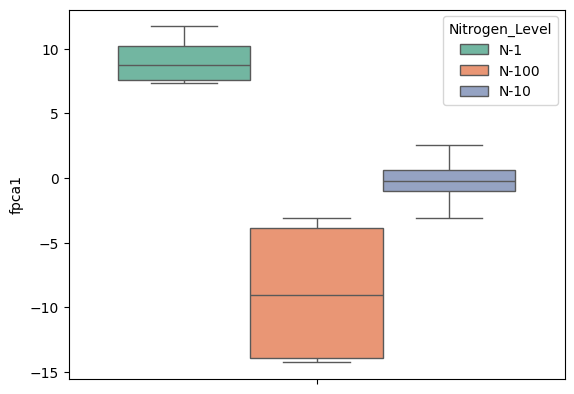

In [10]:
sns.boxplot(
    data=df_LabB_median_short,
    y="fpca1",
    hue="Nitrogen_Level",
    palette="Set2",  
    linewidth=1.0
)